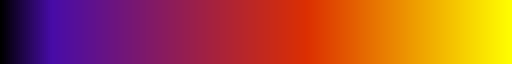

In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

def colorRamp2(colors, positions):
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))
    return cmap

# Specify colors and their positions (0 to 1)
positions = [0, 0.1, 0.6, 1]  # Adjust position to shift purple leftward
colors = ['black',  '#480ca8', '#dc2f02', 'yellow']

# Generate the custom colormap
my_custom_colormap = colorRamp2(colors, positions)
my_custom_colormap

In [62]:
ucell_scores = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/Ucell/pathway/ucell_msigdb_matrix_gw6.csv', index_col=0)
ucell_scores.head()

,NEUROGENESIS_RELATED_UCell,GLIOGENESIS_RELATED_UCell
GW7:4470_6510,0.000000,0.000000
GW7:4680_6420,0.077977,0.000000
GW7:5280_5610,0.041977,0.000000
GW7:4890_5580,0.188841,0.044658
GW7:5190_6510,0.000000,0.000000


In [49]:
coord = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/visualization3/spatial_coord.csv', index_col=0)
coord

,x,y
GW7:4470_6510,4470.0,6510.0
GW7:4680_6420,4680.0,6420.0
GW7:5280_5610,5280.0,5610.0
GW7:4890_5580,4890.0,5580.0
GW7:5190_6510,5190.0,6510.0
...,...,...
GW17:14550_23100,14550.0,23100.0
GW17:14580_23100,14580.0,23100.0
GW17:13980_23010,13980.0,23010.0
GW17:15240_17130,15240.0,17130.0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_spatial_feature(feature_name, df, dot_size=20, cmap='magma', use_robust_scale=True,
                         save_path=None):
    """
    Optimized spatial distribution plot: square lattice markers for a cleaner visual style
    """
    # 1. Prepare data
    x = df['x']
    y = df['y']
    values = df[feature_name]

    # 2. Set contrast optimization (optional)
    # Automatically trim top 1% outliers to avoid color scale skew from extreme values
    if use_robust_scale:
        vmin = values.min()
        vmax = np.percentile(values, 99)
    else:
        vmin, vmax = None, None

    # 3. Start plotting
    fig, ax = plt.subplots(figsize=(7, 7), dpi=100)
    
    # marker='s' uses square markers
    # edgecolors='none' makes neighboring squares look smoother
    sc = ax.scatter(x, y, c=values, s=dot_size, 
                    marker='s', cmap=cmap, 
                    vmin=vmin, vmax=vmax,
                    edgecolors='none')

    # 4. Refine layout
    ax.set_title(f'{feature_name}', fontsize=14, pad=15, fontweight='bold')
    
    # Keep 1:1 coordinate aspect ratio, which is critical for spatial data
    ax.set_aspect('equal', adjustable='box')
    
    # Remove redundant axis ticks (exact pixel coordinates are usually unnecessary for ST data)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 5. Add color bar
    # fraction and pad control color bar position and size
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.outline.set_visible(False) # Remove color bar frame
    cbar.set_label('UCell Score', fontsize=10)

    # 6. Invert Y-axis (common for ST data; uncomment if the figure appears upside-down)
    # ax.invert_yaxis()

    plt.tight_layout()
    # --- Added save logic ---
    if save_path:
        # bbox_inches='tight' automatically trims extra margins
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')

    plt.show()

In [63]:
# Data
plot_df = coord.join(ucell_scores, how='inner')

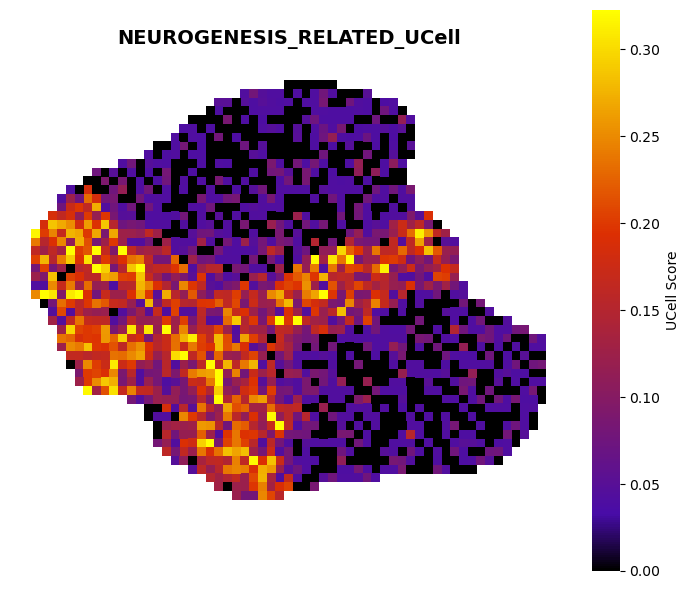

In [64]:
# Distribution
plot_spatial_feature('NEUROGENESIS_RELATED_UCell', plot_df, dot_size=42, cmap=my_custom_colormap, 
                     save_path='./plot/GW6_NEUROGENESIS_RELATED_UCell.pdf')